# Klasifikasi Tingkat Risiko COVID-19 di Indonesia menggunakan Random Forest

**Tugas:** Machine Learning - Random Forest Classifier
**Dataset:** Data COVID-19 Indonesia (time series harian per provinsi)

Notebook ini melakukan:
1. Eksplorasi & pembersihan data
2. Rekayasa fitur (feature engineering) dan pembuatan target klasifikasi
3. Training model Random Forest
4. Evaluasi model (accuracy, confusion matrix, classification report)
5. Analisis feature importance


In [1]:
# 1. Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 2. Load Dataset

In [2]:
df = pd.read_excel("Data_Set_Covid_19_Indonesia.xlsx")
print("Ukuran data:", df.shape)
df.head()


Ukuran data: (31822, 36)


,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,2020-01-03 00:00:00,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699e+09,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,2020-02-03 00:00:00,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699e+09,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,2020-02-03 00:00:00,IDN,Indonesia,2,0,0,2,2,0,0,...,-7.892750e-01,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,2020-02-03 00:00:00,ID-RI,Riau,1,0,0,1,1,0,1,...,5.116479e-01,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,2020-03-03 00:00:00,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699e+09,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         31822 non-null  object 
 1   Location ISO Code            31822 non-null  str    
 2   Location                     31822 non-null  str    
 3   New Cases                    31822 non-null  int64  
 4   New Deaths                   31822 non-null  int64  
 5   New Recovered                31822 non-null  int64  
 6   New Active Cases             31822 non-null  int64  
 7   Total Cases                  31822 non-null  int64  
 8   Total Deaths                 31822 non-null  int64  
 9   Total Recovered              31822 non-null  int64  
 10  Total Active Cases           31822 non-null  int64  
 11  Location Level               31822 non-null  str    
 12  Province                     30893 non-null  str    
 13  Country                    

## 3. Data Cleaning

- Dataset berisi baris level **Province** dan level **Country** (agregat nasional). Untuk analisis per wilayah, kita hanya pakai baris level **Province**.
- Kolom `Date` diparse ke datetime, lalu diekstrak fitur `Month`.


In [4]:
# Hanya ambil baris level Provinsi (buang baris agregat nasional 'Country')
df = df[df["Location Level"] == "Province"].copy()

# Parse tanggal
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Month"] = df["Date"].dt.month

print("Ukuran data setelah filter Province:", df.shape)


Ukuran data setelah filter Province: (30893, 37)


## 4. Membuat Target Klasifikasi

Target yang diprediksi adalah **Tingkat Risiko** (`Risk_Level`) suatu provinsi pada suatu hari, dikategorikan menjadi **Rendah / Sedang / Tinggi** berdasarkan rasio **kasus aktif per juta penduduk** (`Total Active Cases` dibagi `Population`, dikali 1 juta).

Pembagian kelas menggunakan kuantil (33% dan 66%) supaya jumlah data di tiap kelas relatif seimbang.


### Membersihkan kolom rate (persen dalam bentuk teks)

Kolom `Case Fatality Rate` dan `Case Recovered Rate` tersimpan sebagai teks dengan simbol `%` (contoh: `"51.28%"`), sehingga perlu dikonversi ke angka desimal terlebih dahulu.


In [5]:
# Konversi kolom rate dari string 'xx.xx%' menjadi float
for col in ["Case Fatality Rate", "Case Recovered Rate"]:
    df[col] = (
        df[col].astype(str).str.replace("%", "", regex=False).str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[["Case Fatality Rate", "Case Recovered Rate"]].describe()


,Case Fatality Rate,Case Recovered Rate
count,30893.000000,30893.000000
mean,4.092969,87.076151
std,14.605512,144.725339
min,0.000000,0.000000
25%,1.860000,76.500000
50%,2.630000,90.390000
75%,3.740000,96.640000
max,1000.000000,11100.000000


In [6]:
# Hitung kasus aktif per juta penduduk sebagai basis target
df["Active_per_Million"] = (df["Total Active Cases"] / df["Population"]) * 1_000_000

# Buang baris yang tidak valid (populasi/kasus aktif kosong atau tak terhingga)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Active_per_Million"])

# Bagi menjadi 3 kelas berdasarkan kuantil
q1, q2 = df["Active_per_Million"].quantile([0.33, 0.66])

def risk_label(x):
    if x <= q1:
        return "Rendah"
    elif x <= q2:
        return "Sedang"
    else:
        return "Tinggi"

df["Risk_Level"] = df["Active_per_Million"].apply(risk_label)
df["Risk_Level"].value_counts()


Risk_Level
Tinggi    10504
Rendah    10195
Sedang    10194
Name: count, dtype: int64

## 5. Pemilihan Fitur (Feature Selection)

Fitur yang dipakai adalah fitur **demografis** dan **indikator epidemiologi tidak langsung** (bukan turunan langsung dari target), sehingga model belajar pola yang berguna, bukan sekadar menghafal target:

- `Population Density`, `Area (km2)`, `Population`
- `Total Regencies`, `Total Cities`, `Total Districts`
- `Growth Factor of New Cases`, `Growth Factor of New Deaths`
- `Case Fatality Rate`, `Case Recovered Rate`
- `Island` (kategorikal)
- `Month` (musiman)


In [7]:
feature_cols = [
    "Population Density", "Area (km2)", "Population",
    "Total Regencies", "Total Cities", "Total Districts",
    "Growth Factor of New Cases", "Growth Factor of New Deaths",
    "Case Fatality Rate", "Case Recovered Rate",
    "Island", "Month",
]
target_col = "Risk_Level"

data = df[feature_cols + [target_col]].copy()
print("Missing value per kolom:")
print(data.isna().sum())


Missing value per kolom:
Population Density                0
Area (km2)                        0
Population                        0
Total Regencies                   0
Total Cities                    901
Total Districts                   0
Growth Factor of New Cases     1935
Growth Factor of New Deaths    3442
Case Fatality Rate                0
Case Recovered Rate               0
Island                            0
Month                             0
Risk_Level                        0
dtype: int64


In [8]:
# Encode kolom kategorikal 'Island'
le_island = LabelEncoder()
data["Island"] = le_island.fit_transform(data["Island"].astype(str))

# Imputasi nilai kosong pada fitur numerik dengan median
numeric_cols = [c for c in feature_cols if c != "Island"]
imputer = SimpleImputer(strategy="median")
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

# Encode target
le_target = LabelEncoder()
data["Risk_Level_enc"] = le_target.fit_transform(data["Risk_Level"])
print("Mapping kelas target:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

data.head()


Mapping kelas target: {'Rendah': np.int64(0), 'Sedang': np.int64(1), 'Tinggi': np.int64(2)}


,Population Density,Area (km2),Population,Total Regencies,Total Cities,Total Districts,Growth Factor of New Cases,Growth Factor of New Deaths,Case Fatality Rate,Case Recovered Rate,Island,Month,Risk_Level,Risk_Level_enc
0,16334.31,664.0,10846145.0,1.0,5.0,44.0,1.0,1.0,51.28,192.31,0,1.0,Rendah,0
1,16334.31,664.0,10846145.0,1.0,5.0,44.0,1.0,1.0,48.78,182.93,0,2.0,Rendah,0
3,69.80,87024.0,6074100.0,10.0,2.0,169.0,1.0,1.0,0.00,100.00,6,2.0,Rendah,0
4,16334.31,664.0,10846145.0,1.0,5.0,44.0,1.0,1.0,46.51,174.42,0,3.0,Rendah,0
6,1276.55,35378.0,45161325.0,18.0,9.0,627.0,1.0,1.0,100.00,6000.00,0,3.0,Rendah,0


## 6. Split Data Train/Test

In [9]:
X = data[feature_cols]
y = data["Risk_Level_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Data latih:", X_train.shape)
print("Data uji  :", X_test.shape)


Data latih: (24714, 12)
Data uji  : (6179, 12)


## 7. Training Model Random Forest

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Model selesai dilatih.")


Model selesai dilatih.


## 8. Evaluasi Model

In [11]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


Akurasi: 0.9519

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.98      0.97      0.97      2039
      Sedang       0.93      0.93      0.93      2039
      Tinggi       0.95      0.96      0.95      2101

    accuracy                           0.95      6179
   macro avg       0.95      0.95      0.95      6179
weighted avg       0.95      0.95      0.95      6179



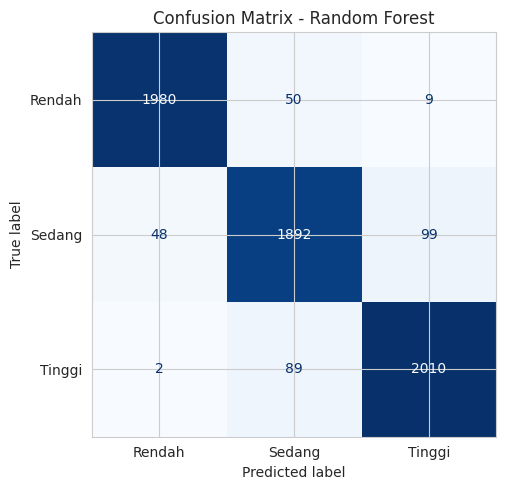

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


## 9. Feature Importance

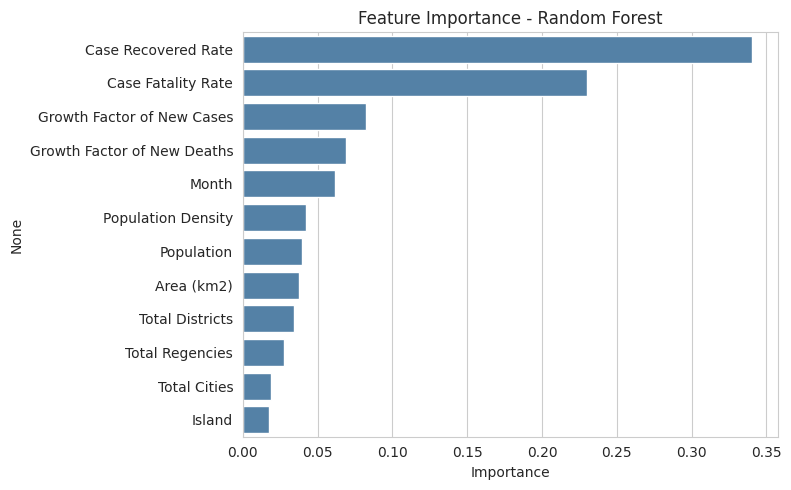

Case Recovered Rate            0.340508
Case Fatality Rate             0.230108
Growth Factor of New Cases     0.082615
Growth Factor of New Deaths    0.068633
Month                          0.061876
Population Density             0.042037
Population                     0.039261
Area (km2)                     0.037287
Total Districts                0.034369
Total Regencies                0.027311
Total Cities                   0.018529
Island                         0.017465
dtype: float64

In [13]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

importances


## 10. Simpan Model

In [14]:
import joblib

joblib.dump(rf_model, "random_forest_covid_model.pkl")
joblib.dump(le_island, "label_encoder_island.pkl")
joblib.dump(le_target, "label_encoder_target.pkl")
joblib.dump(imputer, "imputer.pkl")

print("Model dan preprocessing objects berhasil disimpan.")


Model dan preprocessing objects berhasil disimpan.


## 11. Kesimpulan

- Model Random Forest berhasil dilatih untuk mengklasifikasikan tingkat risiko COVID-19 (Rendah/Sedang/Tinggi) per provinsi berdasarkan fitur demografis dan indikator epidemiologi.
- Hasil akurasi dan feature importance di atas dapat digunakan sebagai dasar pembahasan pada laporan/paper.
- Beberapa hal yang bisa dikembangkan lebih lanjut:
  - Tuning hyperparameter (`n_estimators`, `max_depth`, `min_samples_leaf`) dengan `GridSearchCV`
  - Membandingkan performa dengan algoritma lain (misalnya KNN, SVM, atau Decision Tree tunggal)
  - Menambahkan fitur time-series (lag beberapa hari, rata-rata bergerak) untuk menangkap tren
